In [1]:
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from environment import complex_custom_four_rooms
from inverse_prediction import build_environment_kernel
from analysis_functions import evaluate_held_out_planning

sns.set_theme(style="whitegrid")


# Prelims

In [4]:
PHASE2_BUNDLE_PATH = "phase2_bundle.pkl"
PHASE3_RESULTS_PATH = "phase3_live_results.csv"

LIVE_EVALUATION_SEEDS = [101, 202, 303, 404, 505]
LIVE_ROLLOUTS_PER_TASK = 500
PHASE3_STARTS = [(2, 2), (2, 8), (8, 2), (8, 8)]

with open(PHASE2_BUNDLE_PATH, "rb") as file:
  phase2_bundle = pickle.load(file)

PHASE3_STEPS = phase2_bundle["prediction_steps"]

env = complex_custom_four_rooms()
P_true = build_environment_kernel(env)
model_runs = phase2_bundle["model_runs"]
phase2_model_seed_df = phase2_bundle["phase2_model_seed_df"]
HELD_OUT_GOALS = phase2_bundle["held_out_goals"]
GAMMA = phase2_bundle["gamma"]
AGENT_NAMES = list(phase2_bundle["agents_to_be_trained"])

held_out_df = pd.DataFrame({"held-out goal": HELD_OUT_GOALS})
display(held_out_df)

,held-out goal
0,"(5, 8)"
1,"(2, 4)"
2,"(2, 9)"
3,"(7, 4)"
4,"(7, 9)"


# Value iteration

In [5]:
phase3_live_df, oracle_live_df = evaluate_held_out_planning(env, model_runs, P_true, HELD_OUT_GOALS, PHASE3_STARTS, LIVE_EVALUATION_SEEDS, LIVE_ROLLOUTS_PER_TASK, PHASE3_STEPS, GAMMA)
phase3_live_df.to_csv(PHASE3_RESULTS_PATH, index=False)

Completed held-out goal (5, 8)
Completed held-out goal (2, 4)
Completed held-out goal (2, 9)
Completed held-out goal (7, 4)
Completed held-out goal (7, 9)


In [6]:
key_columns = ["goal", "start", "evaluation seed"]
benchmark_comparison_df = oracle_live_df[key_columns + [
    "live success rate", "live goal-curve AUC", "live mean capped steps"
]].rename(columns={
    "live success rate": "benchmark success rate",
    "live goal-curve AUC": "benchmark goal-curve AUC",
    "live mean capped steps": "benchmark mean capped steps",
})

phase3_comparison_df = phase3_live_df.merge(
    benchmark_comparison_df, on=key_columns, how="left"
)
phase3_comparison_df["success gap"] = (
    phase3_comparison_df["benchmark success rate"]
    - phase3_comparison_df["live success rate"]
)
phase3_comparison_df["goal-AUC gap"] = (
    phase3_comparison_df["benchmark goal-curve AUC"]
    - phase3_comparison_df["live goal-curve AUC"]
)
phase3_comparison_df["capped-step difference"] = (
    phase3_comparison_df["live mean capped steps"]
    - phase3_comparison_df["benchmark mean capped steps"]
)

phase3_metric_columns = [
    "live success rate",
    "live goal-curve AUC",
    "live mean capped steps",
    "success gap",
    "goal-AUC gap",
    "capped-step difference",
]
phase3_model_seed_df = phase3_comparison_df.groupby(["training seed", "model"])[phase3_metric_columns].mean().reset_index()


# Results

In [7]:
phase3_ranking_df = phase3_model_seed_df.groupby("model")[phase3_metric_columns].agg(["mean", "std"]).reindex(AGENT_NAMES)

ranking_order = phase3_model_seed_df.groupby("model").agg(
    success=("live success rate", "mean"),
    goal_auc=("live goal-curve AUC", "mean"),
    capped_steps=("live mean capped steps", "mean"),
    ).sort_values(
        ["success", "goal_auc", "capped_steps"],
        ascending=[False, False, True]
    ).index

print("Held-out live performance by model")
display(phase3_ranking_df.loc[ranking_order].round(3))

benchmark_summary_df = oracle_live_df[["live success rate", "live goal-curve AUC", "live mean capped steps"]].agg(["mean", "std"]).T
print("True-kernel Value Iteration benchmark")
display(benchmark_summary_df.round(3))


Held-out live performance by model


live success rate        live goal-curve AUC         \
                           mean    std                mean    std   
model                                                               
Generalist                0.999  0.000               0.763  0.001   
NE specialist             0.984  0.033               0.732  0.055   
NW specialist             0.940  0.051               0.684  0.029   
SE specialist             0.906  0.063               0.633  0.049   
SW specialist             0.809  0.135               0.550  0.094   

              live mean capped steps        success gap        goal-AUC gap  \
                                mean    std        mean    std         mean   
model                                                                         
Generalist                    12.837  0.026       0.000  0.000        0.001   
NE specialist                 14.393  2.703       0.015  0.033        0.032   
NW specialist                 16.738  1.424       0.059  0.051        0.080   
SE specialist                 19.271  2.372       0.093  0.063        0.131   
SW specialist                 23.291  4.555       0.190  0.135        0.214   

                     capped-step difference         
                 std                   mean    std  
model                                               
Generalist     0.001                  0.034  0.026  
NE specialist  0.055                  1.590  2.703  
NW specialist  0.029                  3.936  1.424  
SE specialist  0.049                  6.469  2.372  
SW specialist  0.094                 10.489  4.555

True-kernel Value Iteration benchmark


,mean,std
live success rate,0.999,0.002
live goal-curve AUC,0.764,0.118
live mean capped steps,12.802,5.880


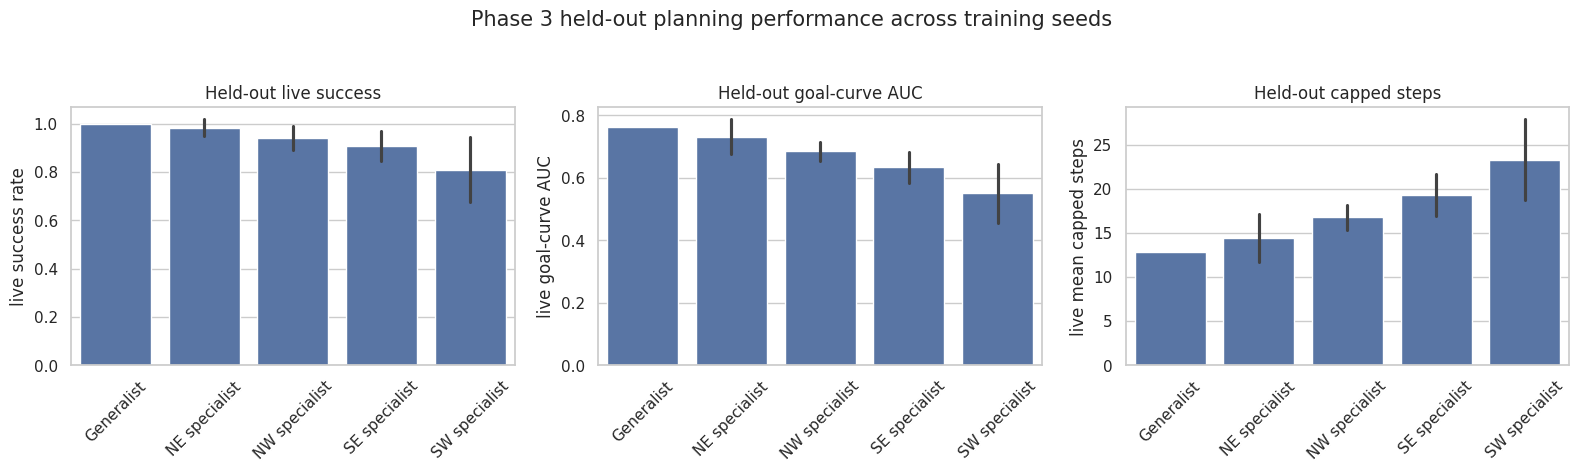

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_data = phase3_model_seed_df.copy()

for ax, metric, title, ascending in [(axes[0], "live success rate", "Held-out live success", False),
          (axes[1], "live goal-curve AUC", "Held-out goal-curve AUC", False), (axes[2], "live mean capped steps", "Held-out capped steps", True)]:
    order = plot_data.groupby("model")[metric].mean().sort_values(ascending=ascending).index
    sns.barplot(data=plot_data, x="model", y=metric, order=order, errorbar="sd", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Phase 3 held-out planning performance across training seeds", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

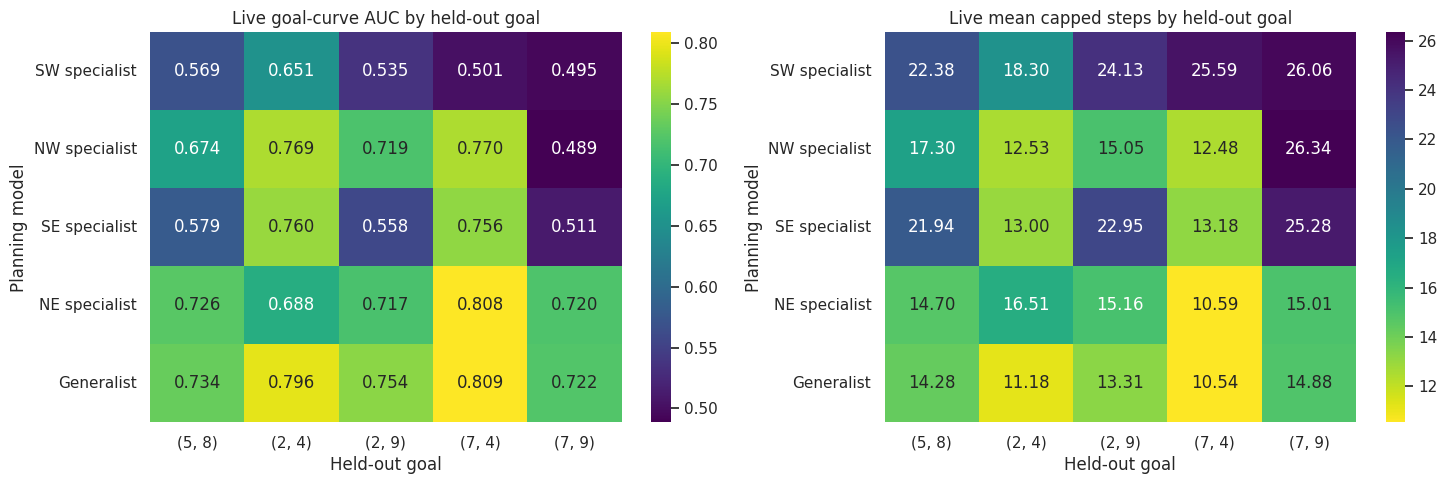

In [9]:
goal_labels = [str(goal) for goal in HELD_OUT_GOALS]
goal_performance = phase3_comparison_df.assign(goal_label=phase3_comparison_df["goal"].astype(str))
goal_auc_df = goal_performance.groupby(["model", "goal_label"])["live goal-curve AUC"].mean().unstack().reindex(index=AGENT_NAMES, columns=goal_labels)
goal_steps_df = goal_performance.groupby(["model", "goal_label"])["live mean capped steps"].mean().unstack().reindex(index=AGENT_NAMES, columns=goal_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(goal_auc_df, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Live goal-curve AUC by held-out goal")
axes[0].set_xlabel("Held-out goal")
axes[0].set_ylabel("Planning model")
sns.heatmap(goal_steps_df, annot=True, fmt=".2f", cmap="viridis_r", ax=axes[1])
axes[1].set_title("Live mean capped steps by held-out goal")
axes[1].set_xlabel("Held-out goal")
axes[1].set_ylabel("Planning model")
plt.tight_layout()
plt.show()

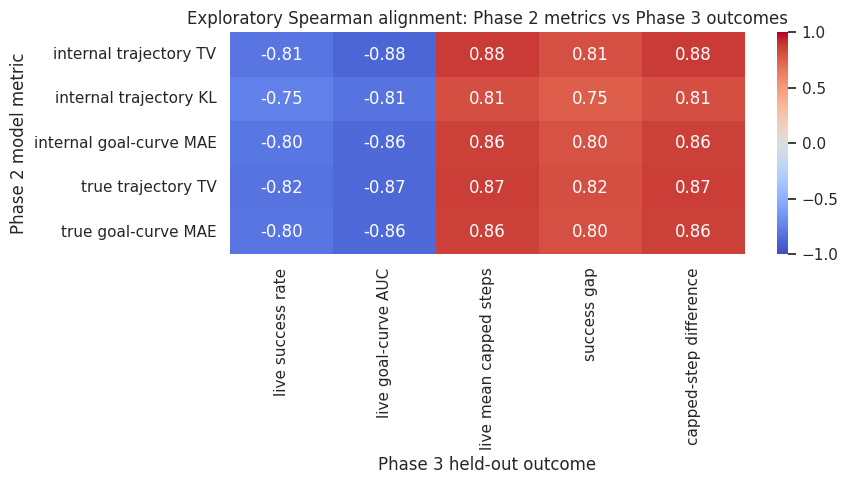

In [10]:
phase2_phase3_df = phase2_model_seed_df.merge(phase3_model_seed_df,left_on=["training seed", "candidate model"], right_on=["training seed", "model"],how="inner")

phase2_columns = [
    "internal trajectory TV",
    "internal trajectory KL",
    "internal goal-curve MAE",
    "true trajectory TV",
    "true goal-curve MAE",
]
phase3_columns = [
    "live success rate",
    "live goal-curve AUC",
    "live mean capped steps",
    "success gap",
    "capped-step difference",
]
alignment_df = phase2_phase3_df[phase2_columns + phase3_columns].corr(method="spearman").loc[phase2_columns, phase3_columns]

plt.figure(figsize=(9, 5))
sns.heatmap(alignment_df, annot=True, fmt=".2f", center=0.0, cmap="coolwarm", vmin=-1.0, vmax=1.0)
plt.title("Exploratory Spearman alignment: Phase 2 metrics vs Phase 3 outcomes")
plt.xlabel("Phase 3 held-out outcome")
plt.ylabel("Phase 2 model metric")
plt.tight_layout()
plt.show()


In [11]:
combined_model_summary_df = phase2_phase3_df.groupby("model").agg(
    phase3_success=("live success rate", "mean"),
    phase3_goal_auc=("live goal-curve AUC", "mean"),
    phase3_capped_steps=("live mean capped steps", "mean"),
    phase3_success_gap=("success gap", "mean"),
    phase2_internal_tv=("internal trajectory TV", "mean"),
    phase2_internal_kl=("internal trajectory KL", "mean"),
    phase2_internal_goal_error=("internal goal-curve MAE", "mean"),
    phase2_true_tv=("true trajectory TV", "mean"),
    phase2_true_goal_error=("true goal-curve MAE", "mean"),
).loc[ranking_order]

print("Phase 3 ranking with separate Phase 2 metrics")
display(combined_model_summary_df.round(3))

Phase 3 ranking with separate Phase 2 metrics


,phase3_success,phase3_goal_auc,phase3_capped_steps,phase3_success_gap,phase2_internal_tv,phase2_internal_kl,phase2_internal_goal_error,phase2_true_tv,phase2_true_goal_error
model,,,,,,,,,
Generalist,0.999,0.763,12.837,0.000,0.013,0.038,0.005,0.011,0.004
NE specialist,0.984,0.732,14.393,0.015,0.146,0.754,0.120,0.145,0.120
NW specialist,0.940,0.684,16.738,0.059,0.291,3.692,0.247,0.290,0.247
SE specialist,0.906,0.633,19.271,0.093,0.377,4.680,0.321,0.377,0.321
SW specialist,0.809,0.550,23.291,0.190,0.450,5.776,0.385,0.450,0.386
